<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 5.14}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Alumna:} & Flores Perusquia Ricardo \\[6pt]
\textbf{Fecha de realización:} & 13/05/2026
\end{array}

</center>


**UNAM y la creadora del presente notebook, no guarda relación alguna con las marcas mencionadas como ejemplo. Las marcas son propiedad de sus titulares conforme a la legislación aplicable, se utilizan con fines académicos y didácticos, por lo que no existen fines de lucro, relación publicitaria o de patrocinio.

---

In [5]:
!pip install opencv-python

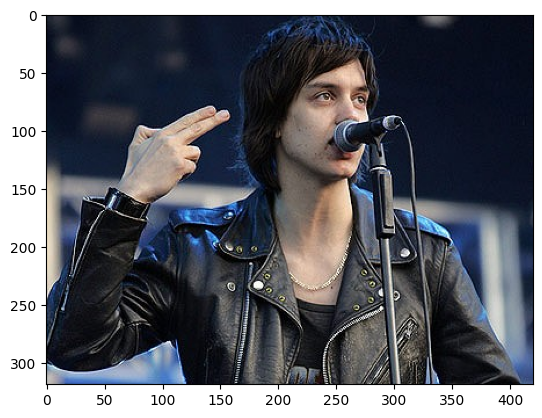

In [6]:
import matplotlib.pyplot as plt
import cv2 as cv
import numpy as np

img = cv.imread('/content/JulianC.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.imshow(img, cmap='gray')

#Rotación

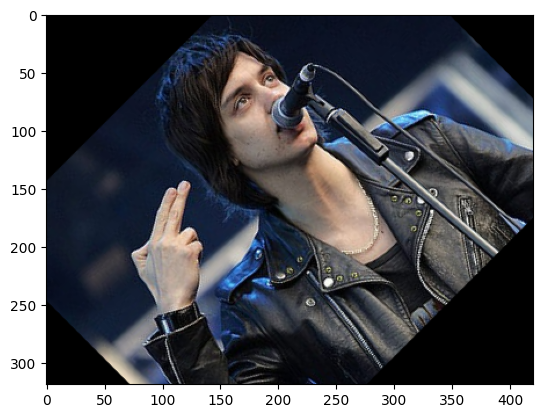

In [7]:
centro = (img.shape[1]//2,img.shape[0]//2)
matriz_rot = cv.getRotationMatrix2D(centro,45,1)
img_rot = cv.warpAffine(img, matriz_rot,(img.shape[1],img.shape[0]))
plt.imshow(img_rot, cmap='gray')

Las dimensiones de la imagen nueva son :  (424, 424)


/tmp/ipykernel_22119/2213408124.py:1: DeprecationWarning: numpy.core.multiarray is deprecated and has been renamed to numpy._core.multiarray. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.min_scalar_type.
  from numpy.core.multiarray import min_scalar_type


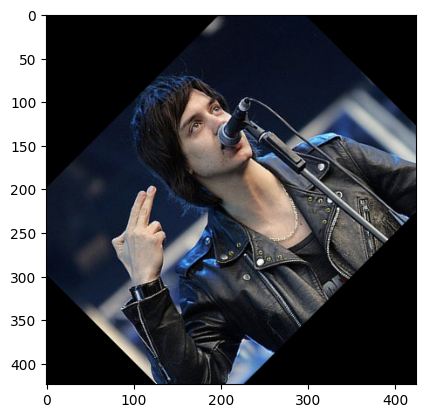

In [8]:
from numpy.core.multiarray import min_scalar_type
import numpy as np

esq_orig = [(0,0,1),(400,0,1),(0,200,1),(400,200,1)]
esq_nueva = [np.matmul(matriz_rot,pt) for pt in esq_orig]

min_x=np.min([pt[0] for pt in esq_nueva])
max_x=np.max([pt[0] for pt in esq_nueva])

min_y=np.min([pt[1] for pt in esq_nueva])
max_y=np.max([pt[1] for pt in esq_nueva])

dim_nueva=(int(max_y-min_y),int(max_x-min_x) )

print('Las dimensiones de la imagen nueva son : ', dim_nueva)

centro_nuevo = (dim_nueva[0]//2, dim_nueva[1]//2)
tras_Centro = (centro_nuevo[0] - centro[0], centro_nuevo[1] - centro[1])

matriz_rot[0][2] += tras_Centro[0]
matriz_rot[1][2] += tras_Centro[1]

img_rot2 = cv.warpAffine(img, matriz_rot,dim_nueva)
plt.imshow(img_rot2,cmap = 'gray')


#Traslación

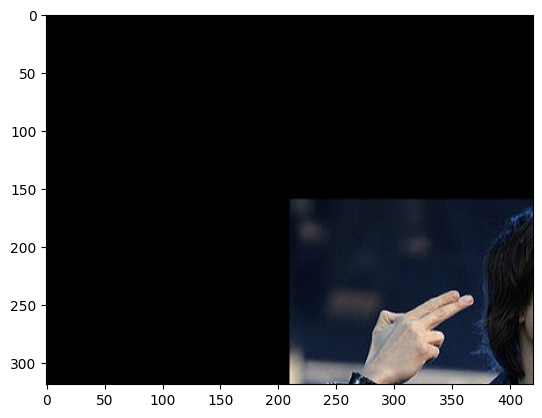

In [9]:
alto, ancho = img.shape[:2]
tx, ty = ancho/2, alto/2
matriz_tras = np.array([[1,0,tx],[0,1,ty]], dtype=np.float32)
img_tras =  cv.warpAffine(src = img, M=matriz_tras, dsize=(ancho, alto))
plt.imshow(img_tras, cmap='gray')



In [10]:
ancho

420

#Escalamiento

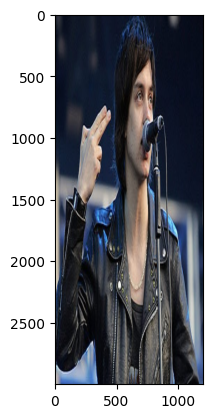

In [11]:
ancho_red = 800
alto_red = 5000
puntos_red = (ancho_red, alto_red)
img_red = cv.resize(img, puntos_red, interpolation=cv.INTER_LINEAR)
plt.imshow(img_red, cmap = 'gray')

Altura y ancho de la imagen original 319 x 420
Altura y ancho de la imagen modificada 957 x 1260


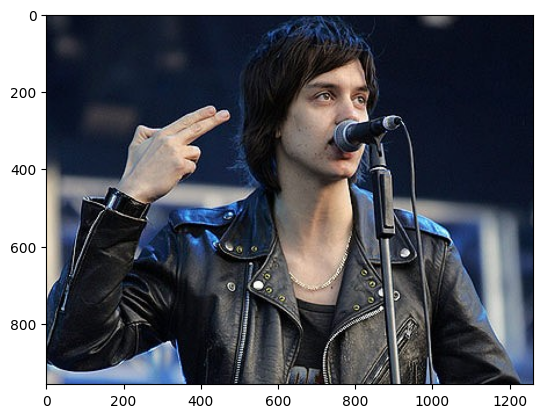

In [12]:
h,w,c =img.shape
print("Altura y ancho de la imagen original", h, "x",w)

esca_red_x = 3
esca_red_y = 3

img_red = cv.resize(img, None, fx=esca_red_x, fy=esca_red_y, interpolation =cv.INTER_AREA)
plt.imshow (img_red, cmap='gray')
h,w,c = img_red.shape
print("Altura y ancho de la imagen modificada", h, "x",w)

#Conclusión

Las transformaciones geométricas constituyen una herramienta fundamental en el preprocesamiento de imágenes para sistemas de inteligencia artificial. Operaciones como rotación, traslación y escalamiento permiten aumentar la variabilidad de los datos (data augmentation), corregir alineaciones y adaptar imágenes a dimensiones fijas exigidas por modelos de deep learning. El manejo adecuado de matrices de transformación afín (warpAffine) y el cuidado del espacio de visualización (cálculo de nuevas dimensiones) son habilidades prácticas esenciales para cualquier proyecto de visión por computadora.

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>